In [145]:
import pandas as pd
import numpy as np 
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL
import requests
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen


In [146]:
final_df = pd.read_csv("final_df.csv", index_col=0)
final_df.index = pd.PeriodIndex(final_df.index, freq="Q")
# I had this issue when i took the log that some of my values were as -inf and +inf, im just replaincg them with Nan
final_df.replace([np.inf, -np.inf], np.nan, inplace=True)

final_df

,ShortRate,ShortRate_Change,PolicyRate,PolicyRate_Change,RealGDP,RealGDP_Log,RealGDP_Log_Change,GDP Deflator_logged,GDP Deflators CPI Proxy,CPI,Log_Dif_Growth,Log_YoY_Growth,CPI Growth Rate
date,,,,,,,,,,,,,
1960Q2,4.963333,0.393333,5.333333,0.333333,168948.0,12.037346,-0.006919,1.677209,0.016328,6.59,0.003040,1.221389,0.606980
1960Q3,5.570000,0.606667,6.000000,0.666667,171442.0,12.052000,0.014654,1.676828,-0.000382,6.59,0.000000,1.221389,0.150830
1960Q4,4.693333,-0.876667,5.333333,-0.666667,172382.0,12.057468,0.005468,1.691078,0.014250,6.70,0.016554,1.655418,1.054217
1961Q1,4.353333,-0.340000,5.000000,-0.333333,175276.0,12.074117,0.016649,1.699609,0.008531,6.72,0.002981,2.257432,0.536513
1961Q2,4.463333,0.110000,5.000000,0.000000,175974.0,12.078092,0.003974,1.695512,-0.004097,6.77,0.007413,2.694774,1.245182
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015Q4,0.471600,0.003033,0.500000,0.000000,621968.0,13.340644,0.005975,4.687885,0.005442,100.29,0.001497,0.059844,0.199601
2016Q1,0.469233,-0.002367,0.500000,0.000000,625099.0,13.345665,0.005021,4.693441,0.005555,99.84,-0.004497,0.351177,-0.298805
2016Q2,0.423133,-0.046100,0.500000,0.000000,629697.0,13.352994,0.007329,4.696005,0.002564,100.43,0.005892,0.359103,0.699301


Output Gap 

In [147]:
# Applying the HP Filter so that I can mannually extract the output gap. 

cycle, potential_output = sm.tsa.filters.hpfilter(final_df["RealGDP_Log"], lamb=1600)

final_df["potential_output"] = potential_output
final_df["Output_Gap"] = cycle * 100

final_df



,ShortRate,ShortRate_Change,PolicyRate,PolicyRate_Change,RealGDP,RealGDP_Log,RealGDP_Log_Change,GDP Deflator_logged,GDP Deflators CPI Proxy,CPI,Log_Dif_Growth,Log_YoY_Growth,CPI Growth Rate,potential_output,Output_Gap
date,,,,,,,,,,,,,,,
1960Q2,4.963333,0.393333,5.333333,0.333333,168948.0,12.037346,-0.006919,1.677209,0.016328,6.59,0.003040,1.221389,0.606980,12.036013,0.133284
1960Q3,5.570000,0.606667,6.000000,0.666667,171442.0,12.052000,0.014654,1.676828,-0.000382,6.59,0.000000,1.221389,0.150830,12.043697,0.830376
1960Q4,4.693333,-0.876667,5.333333,-0.666667,172382.0,12.057468,0.005468,1.691078,0.014250,6.70,0.016554,1.655418,1.054217,12.051380,0.608773
1961Q1,4.353333,-0.340000,5.000000,-0.333333,175276.0,12.074117,0.016649,1.699609,0.008531,6.72,0.002981,2.257432,0.536513,12.059071,1.504585
1961Q2,4.463333,0.110000,5.000000,0.000000,175974.0,12.078092,0.003974,1.695512,-0.004097,6.77,0.007413,2.694774,1.245182,12.066779,1.131274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015Q4,0.471600,0.003033,0.500000,0.000000,621968.0,13.340644,0.005975,4.687885,0.005442,100.29,0.001497,0.059844,0.199601,13.337581,0.306300
2016Q1,0.469233,-0.002367,0.500000,0.000000,625099.0,13.345665,0.005021,4.693441,0.005555,99.84,-0.004497,0.351177,-0.298805,13.343377,0.228865
2016Q2,0.423133,-0.046100,0.500000,0.000000,629697.0,13.352994,0.007329,4.696005,0.002564,100.43,0.005892,0.359103,0.699301,13.349183,0.381106


Annualising eveything

In [148]:
stl = STL(final_df["Log_Dif_Growth"].dropna(), period=4)
res = stl.fit()
final_df["Log Dif Growth Seasonally Adjusted"] = res.trend + res.resid
final_df["Log Dif Growth Seasonally Adjusted"] = final_df["Log Dif Growth Seasonally Adjusted"] * 4

# Seasonally adjust CPI Growth Rate
stl_cpi = STL(final_df["CPI Growth Rate"].dropna(), period=4)
res_cpi = stl_cpi.fit()
final_df["CPI Growth Rate Seasonally Adjusted"] = res_cpi.trend + res_cpi.resid
final_df["CPI Growth Rate Seasonally Adjusted"] = final_df["CPI Growth Rate Seasonally Adjusted"] * 4

Annualising 

In [149]:
final_df["CPI_Log_Inflation_Annualised"]         = final_df["Log_Dif_Growth"] * 4 * 100
final_df["CPI_Inflation_Annualised"] = final_df["CPI Growth Rate"] * 4
final_df["Output_Gap_Annualised"]         = final_df["Output_Gap"] * 4

final_df.head(10)

,ShortRate,ShortRate_Change,PolicyRate,PolicyRate_Change,RealGDP,RealGDP_Log,RealGDP_Log_Change,GDP Deflator_logged,GDP Deflators CPI Proxy,CPI,Log_Dif_Growth,Log_YoY_Growth,CPI Growth Rate,potential_output,Output_Gap,Log Dif Growth Seasonally Adjusted,CPI Growth Rate Seasonally Adjusted,CPI_Log_Inflation_Annualised,CPI_Inflation_Annualised,Output_Gap_Annualised
date,,,,,,,,,,,,,,,,,,,,
1960Q2,4.963333,0.393333,5.333333,0.333333,168948.0,12.037346,-0.006919,1.677209,0.016328,6.59,0.003040,1.221389,0.606980,12.036013,0.133284,0.015550,1.397377,1.215806,2.427921,0.533135
1960Q3,5.570000,0.606667,6.000000,0.666667,171442.0,12.052000,0.014654,1.676828,-0.000382,6.59,0.000000,1.221389,0.150830,12.043697,0.830376,0.016592,1.783859,0.000000,0.603318,3.321503
1960Q4,4.693333,-0.876667,5.333333,-0.666667,172382.0,12.057468,0.005468,1.691078,0.014250,6.70,0.016554,1.655418,1.054217,12.051380,0.608773,0.036951,3.742062,6.621671,4.216867,2.435093
1961Q1,4.353333,-0.340000,5.000000,-0.333333,175276.0,12.074117,0.016649,1.699609,0.008531,6.72,0.002981,2.257432,0.536513,12.059071,1.504585,0.023168,2.413285,1.192251,2.146051,6.018341
1961Q2,4.463333,0.110000,5.000000,0.000000,175974.0,12.078092,0.003974,1.695512,-0.004097,6.77,0.007413,2.694774,1.245182,12.066779,1.131274,0.024090,3.334757,2.965173,4.980729,4.525097
1961Q3,6.646667,2.183333,7.000000,2.000000,175126.0,12.073261,-0.004831,1.734528,0.039016,6.85,0.011748,3.869530,1.259151,12.074522,-0.126121,0.066150,6.964641,4.699026,5.036603,-0.504483
1961Q4,5.506667,-1.140000,6.166667,-0.833333,174768.0,12.071215,-0.002046,1.724741,-0.009788,6.96,0.015931,3.807195,1.127820,12.082328,-1.111317,0.047318,4.516005,6.372329,4.511278,-4.445266
1962Q1,5.060000,-0.446667,5.666667,-0.500000,175568.0,12.075782,0.004567,1.733785,0.009044,7.01,0.007158,4.224955,1.002288,12.090221,-1.443947,0.034113,3.760991,2.863291,4.009151,-5.775788
1962Q2,3.930000,-1.130000,4.500000,-1.166667,177216.0,12.085125,0.009343,1.748677,0.014892,7.16,0.021172,5.600889,2.129075,12.098221,-1.309623,0.070846,6.281952,8.468912,8.516301,-5.238491


Importing my Instrumental variables

In [150]:
import requests
import pandas as pd
import numpy as np

API_KEY = "51286e2abae242cda74d0d166f50b652"
BASE_URL = "https://api.stlouisfed.org/fred/series/observations"
START = "1955-04-01"
END   = "2023-10-01"


def fetch(series_id, col_name):
    params = {
        "series_id": series_id,
        "api_key": API_KEY,
        "file_type": "json",
        "observation_start": START,
        "observation_end": END,
    }
    r = requests.get(BASE_URL, params=params)
    r.raise_for_status()
    df = pd.DataFrame(r.json()["observations"])[["date", "value"]].copy()
    df["date"] = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.set_index("date")
    df = df.resample("QS").mean()
    df.index = pd.PeriodIndex(df.index, freq="Q")
    df = df.rename(columns={"value": col_name})
    return df


# Unemployment rate — OECD harmonised monthly (LRHUTTTTGBM156S confirmed)
unemp = fetch("LRHUTTTTGBM156S", "Unemployment_Rate")

# Employment level — Bank of England long-run quarterly (EMPUKQ confirmed)
emp = fetch("EMPUKQ", "Employment_raw")
emp["Employment_Growth"] = np.log(emp["Employment_raw"]).diff() * 100
emp = emp[["Employment_Growth"]]

# Long-term government bond yield: 10-year — OECD monthly (IRLTLT01GBM156N confirmed)
longrate = fetch("IRLTLT01GBM156N", "LongRate")

# M1 narrow money — OECD monthly (MANMM101GBM189S confirmed)
m1 = fetch("MANMM101GBM189S", "M1_raw")
m1["M1_Growth"] = np.log(m1["M1_raw"]).diff() * 100
m1 = m1[["M1_Growth"]]

# M3 broad money — OECD monthly (MABMM301GBM189S confirmed)
m3 = fetch("MABMM301GBM189S", "M3_raw")
m3["M3_Growth"] = np.log(m3["M3_raw"]).diff() * 100
m3 = m3[["M3_Growth"]]

# Credit to private sector — BIS quarterly (QGBPAM770A confirmed)
credit = fetch("QGBPAM770A", "Credit_raw")
credit["Credit_Growth"] = np.log(credit["Credit_raw"]).diff() * 100
credit = credit[["Credit_Growth"]]

# Government gross debt as % of GDP — IMF annual (best available, quarterly NaNs expected)
debt_gdp = fetch("GGGDTAGBA188N", "Debt_to_GDP")

# Government final consumption expenditure — OECD quarterly from Q1 1955
gov_exp = fetch("GBRGFCEQDSNAQ", "GovExp")
gov_exp["GovExp_Growth"] = np.log(gov_exp["GovExp"]).diff() * 100
gov_exp = gov_exp[["GovExp_Growth"]]

# GBP/USD exchange rate — daily (DEXUSUK confirmed)
fx = fetch("DEXUSUK", "GBPUSD_raw")
fx["GBPUSD_LogDiff"] = np.log(fx["GBPUSD_raw"]).diff() * 100
fx = fx[["GBPUSD_LogDiff"]]

# House price index — BIS quarterly (QGBR628BIS confirmed)
hpi = fetch("QGBR628BIS", "HPI_raw")
hpi["HPI_Growth"] = np.log(hpi["HPI_raw"]).diff() * 100
hpi = hpi[["HPI_Growth"]]

# Equity/share prices — OECD monthly (SPASTT01GBM661N confirmed)
equity = fetch("SPASTT01GBM661N", "Equity_raw")
equity["Equity_Return"] = np.log(equity["Equity_raw"]).diff() * 100
equity = equity[["Equity_Return"]]

# Brent crude oil price — daily (DCOILBRENTEU confirmed)
oil = fetch("DCOILBRENTEU", "Oil_raw")
oil["Oil_LogDiff"] = np.log(oil["Oil_raw"]).diff() * 100
oil = oil[["Oil_LogDiff"]]



# Consumer confidence — OECD monthly (LOCCALTT02GBM661N confirmed)
consumer_conf = fetch("CSCICP02GBM460S", "ConsumerConfidence")


frames = [
    unemp, emp, longrate, m1, m3, credit,
    debt_gdp, gov_exp, fx, hpi, equity, oil, consumer_conf,
]

df_all = frames[0]
for f in frames[1:]:
    df_all = df_all.join(f, how="outer")

df_Instruments = df_all



In [151]:
df_Instruments = df_all.copy()

df_Instruments = df_Instruments.loc["1988Q1":]

df_Instruments

,Unemployment_Rate,Employment_Growth,LongRate,M1_Growth,M3_Growth,Credit_Growth,Debt_to_GDP,GovExp_Growth,GBPUSD_LogDiff,HPI_Growth,Equity_Return,Oil_LogDiff,ConsumerConfidence
date,,,,,,,,,,,,,
1988Q1,9.066667,0.856536,9.483333,3.007859,3.457441,2.684725,37.075,0.367198,2.426983,3.684134,-1.709968,-13.206267,-2.333333
1988Q2,8.666667,0.676135,9.373333,3.657296,3.399059,3.896597,NaN,-0.146053,2.277169,3.967067,1.768759,2.986009,-2.966667
1988Q3,8.366667,0.728950,9.950000,2.968449,5.069511,2.825934,NaN,-0.869099,-8.229420,11.556587,0.807379,-11.853787,-4.666667
1988Q4,7.866667,0.742648,9.896667,2.099120,3.336588,1.230785,NaN,1.402487,5.537378,4.887712,-0.542551,-5.424868,-8.633333
1989Q1,7.500000,0.887719,9.853333,3.594169,4.271475,2.913315,32.533,-0.739553,-2.628703,1.114954,10.152504,25.992275,-11.233333
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022Q4,3.900000,NaN,3.676067,-2.759948,-0.087787,-2.055094,NaN,-0.569852,-0.108801,-2.756846,-0.308317,-12.669999,-38.083333
2023Q1,3.966667,NaN,3.543533,-1.926414,-0.686793,-2.715713,100.354,-0.835356,3.344206,-3.205266,6.533196,-9.026363,-33.000000
2023Q2,4.166667,NaN,3.992767,-2.836972,-1.100904,-2.579439,NaN,2.203101,2.967624,-3.081923,-0.853354,-3.871004,-20.333333


running stationarity tests on my instruments

In [152]:
variable_which_need_station_test = {
    "Unemployment Rate" : df_all["Unemployment_Rate"],
    "Employment Growth"              : df_all["Employment_Growth"],
    "LongRate"               : df_all["LongRate"],
    "M1_Growth"               : df_all["M1_Growth"],
    "M3_Growth"  : df_all["M3_Growth"],
    "Credit Growth" : df_all["Credit_Growth"],
    "Debt to GDP ratio" : df_all["Debt_to_GDP"],
    "Government Expenditure Growth": df_all["GovExp_Growth"],
    "GBPUSD Exchnage Log Diff" : df_all["GBPUSD_LogDiff"],
    "Houseing Price Index" : df_all["HPI_Growth"],
    "Return on Equity" : df_all["Equity_Return"],
    "Log difference Oil": df_all["Oil_LogDiff"],
    "Consumer Confidence" : df_all["ConsumerConfidence"],
}


for series_name, series in variable_which_need_station_test.items():
    stationary_series = series.dropna()
    ADF_test = adfuller(stationary_series, autolag="AIC")
    KPSS_test = kpss(stationary_series, regression="c", nlags="auto")
    
    print(f"\n{'='*50}")
    print(f"Variable: {series_name}  (n={len(stationary_series)})")
    
    print(f"\n  ADF Test:")
    print(f"    Statistic : {ADF_test[0]:.4f}")
    print(f"    p-value   : {ADF_test[1]:.4f}")
    print(f"    Lags used : {ADF_test[2]}")
    print(f"    --> Unit root: {'YES' if ADF_test[1] > 0.05 else 'NO'}")
    
    print(f"\n  KPSS Test:")
    print(f"    Statistic : {KPSS_test[0]:.4f}")
    print(f"    p-value   : {KPSS_test[1]:.4f}")
    print(f"    --> Stationary: {'YES' if KPSS_test[1] > 0.05 else 'NO'}")


Variable: Unemployment Rate  (n=164)

  ADF Test:
    Statistic : -2.0088
    p-value   : 0.2827
    Lags used : 1
    --> Unit root: YES

  KPSS Test:
    Statistic : 1.2222
    p-value   : 0.0100
    --> Stationary: NO

Variable: Employment Growth  (n=246)

  ADF Test:
    Statistic : -5.2866
    p-value   : 0.0000
    Lags used : 7
    --> Unit root: NO

  KPSS Test:
    Statistic : 0.2237
    p-value   : 0.1000
    --> Stationary: YES

Variable: LongRate  (n=256)

  ADF Test:
    Statistic : -1.1202
    p-value   : 0.7070
    Lags used : 2
    --> Unit root: YES

  KPSS Test:
    Statistic : 1.4175
    p-value   : 0.0100
    --> Stationary: NO

Variable: M1_Growth  (n=149)

  ADF Test:
    Statistic : -6.9444
    p-value   : 0.0000
    Lags used : 0
    --> Unit root: NO

  KPSS Test:
    Statistic : 0.7284
    p-value   : 0.0110
    --> Stationary: NO

Variable: M3_Growth  (n=148)

  ADF Test:
    Statistic : -3.5719
    p-value   : 0.0063
    Lags used : 3
    --> Unit root: NO


Descriptive Statistics

In [153]:
df_Instruments.describe()


,Unemployment_Rate,Employment_Growth,LongRate,M1_Growth,M3_Growth,Credit_Growth,Debt_to_GDP,GovExp_Growth,GBPUSD_LogDiff,HPI_Growth,Equity_Return,Oil_LogDiff,ConsumerConfidence
count,144.000000,116.000000,144.000000,144.000000,144.000000,144.000000,36.000000,144.000000,143.000000,144.000000,144.000000,143.000000,144.000000
mean,6.345833,0.188805,4.863906,2.063633,1.706357,0.319865,59.403083,0.464936,-0.228619,0.613701,0.987661,1.104210,-9.904861
std,1.836693,0.398560,3.006421,2.049914,1.713403,1.632558,26.027517,2.541824,4.093475,2.631457,5.471686,16.121487,8.860841
min,3.700000,-0.965825,0.251367,-2.836972,-1.869423,-3.550669,28.480000,-20.206842,-18.720434,-6.947075,-22.997667,-73.433914,-39.000000
25%,4.900000,0.019233,2.191033,1.067936,0.520566,-0.773470,37.891500,-0.178119,-1.943177,-0.994512,-1.679816,-8.025155,-15.250000
50%,5.850000,0.241721,4.608200,2.061698,1.675870,0.372845,43.683500,0.438936,0.015037,0.932243,1.337264,2.523011,-7.233333
75%,7.841667,0.451449,7.046317,2.908487,2.697074,1.384450,85.829000,1.042952,2.000881,2.076550,4.328234,9.452450,-3.741667
max,10.633333,0.887719,12.316667,11.914411,8.158481,5.416709,105.840000,16.629205,10.702513,11.556587,10.955716,49.114651,1.866667


Merging my infaltion and my Policy rate columns into my testing dataframe and then running regressons 

In [154]:
testing_df_IV = df_Instruments[["Unemployment_Rate", "Employment_Growth", "LongRate", "M1_Growth", "M3_Growth", "Credit_Growth", "Debt_to_GDP", "GovExp_Growth", "GBPUSD_LogDiff", "HPI_Growth", "Equity_Return", "Oil_LogDiff", "ConsumerConfidence"]].copy()
testing_df_policy = final_df["PolicyRate"].copy()
testing_df_target = final_df["CPI_Log_Inflation_Annualised"].copy()

testing_df_merged = testing_df_IV.join(testing_df_policy).join(testing_df_target)

testing_df_merged.head(10)

,Unemployment_Rate,Employment_Growth,LongRate,M1_Growth,M3_Growth,Credit_Growth,Debt_to_GDP,GovExp_Growth,GBPUSD_LogDiff,HPI_Growth,Equity_Return,Oil_LogDiff,ConsumerConfidence,PolicyRate,CPI_Log_Inflation_Annualised
date,,,,,,,,,,,,,,,
1988Q1,9.066667,0.856536,9.483333,3.007859,3.457441,2.684725,37.075,0.367198,2.426983,3.684134,-1.709968,-13.206267,-2.333333,8.546667,1.072719
1988Q2,8.666667,0.676135,9.373333,3.657296,3.399059,3.896597,NaN,-0.146053,2.277169,3.967067,1.768759,2.986009,-2.966667,8.046667,8.076139
1988Q3,8.366667,0.728950,9.950000,2.968449,5.069511,2.825934,NaN,-0.869099,-8.229420,11.556587,0.807379,-11.853787,-4.666667,11.380000,2.896814
1988Q4,7.866667,0.742648,9.896667,2.099120,3.336588,1.230785,NaN,1.402487,5.537378,4.887712,-0.542551,-5.424868,-8.633333,12.546667,5.019486
1989Q1,7.500000,0.887719,9.853333,3.594169,4.271475,2.913315,32.533,-0.739553,-2.628703,1.114954,10.152504,25.992275,-11.233333,12.880000,3.704095
1989Q2,7.100000,0.525132,10.300000,7.589990,4.695485,2.541681,NaN,0.450021,-7.077102,1.311224,5.479616,6.761089,-14.500000,13.460000,8.844425
1989Q3,6.966667,0.242877,10.090000,11.914411,4.991042,2.101319,NaN,1.543816,-1.759805,2.752805,9.427553,-8.082415,-14.166667,13.780000,2.600392
1989Q4,6.800000,0.316721,10.520000,3.257304,4.238682,0.847064,NaN,-0.457861,-0.766283,-3.533650,-3.086961,9.643143,-18.733333,14.880000,6.127779
1990Q1,6.766667,0.074377,11.546667,2.279405,3.899920,5.026183,28.480,0.882774,4.330818,-3.305709,2.167292,3.554784,-19.266667,14.880000,4.850353


In [158]:
final_df[["PolicyRate", "CPI_Log_Inflation_Annualised", "Output_Gap_Annualised"]].describe()

,PolicyRate,CPI_Log_Inflation_Annualised,Output_Gap_Annualised
count,227.000000,227.000000,2.270000e+02
mean,6.966564,4.824041,1.630805e-11
std,4.058051,5.194867,6.168406e+00
min,0.250000,-2.964163,-1.548569e+01
25%,4.666667,1.472624,-3.564264e+00
50%,6.166667,3.340133,-7.082135e-01
75%,9.905000,6.686797,3.023783e+00
max,17.000000,33.681480,2.268222e+01


Running my regressions

In [155]:
instrumental_variables = testing_df_merged[["Unemployment_Rate", "Employment_Growth", "LongRate", "M1_Growth", "M3_Growth", "Credit_Growth", "Debt_to_GDP", "GovExp_Growth", "GBPUSD_LogDiff", "HPI_Growth", "Equity_Return", "Oil_LogDiff", "ConsumerConfidence"]]
policy_rate = testing_df_merged["PolicyRate"]
inflation = testing_df_merged["CPI_Log_Inflation_Annualised"]   
output_gap = final_df["Output_Gap_Annualised"]

iv_names = instrumental_variables.columns.tolist()

base = pd.concat([policy_rate, inflation, output_gap, instrumental_variables], axis=1).dropna()
y_pi  = base["CPI_Log_Inflation_Annualised"]
y_i   = base["PolicyRate"]
y_gap = base["Output_Gap_Annualised"]
Z     = base[iv_names]

def first_stage(endog, instrument_col, controls=None):
    X = pd.DataFrame({"const": 1.0, instrument_col: base[instrument_col]})
    if controls is not None:
        for c in controls:
            X[c] = base[c]
    model  = sm.OLS(endog, X).fit()
    resids = model.resid
    fstat  = model.fvalue
    r2     = model.rsquared
    pval   = model.f_pvalue
    return fstat, r2, pval, resids, model

results = []

print("=" * 70)
print("FIRST-STAGE REGRESSIONS: each z_t candidate → PolicyRate")
print("Controls: constant only  (add OutputGap as control if desired)")
print("=" * 70)

for z in iv_names:
    clean = base[["PolicyRate", z]].dropna()
    X = sm.add_constant(clean[z])
    m = sm.OLS(clean["PolicyRate"], X).fit()
    t_z   = m.tvalues[z]
    p_z   = m.pvalues[z]
    fstat = m.fvalue
    r2    = m.rsquared
    stars = "***" if p_z < 0.01 else "**" if p_z < 0.05 else "*" if p_z < 0.1 else ""
    results.append({
        "Instrument": z,
        "Coef":       round(m.params[z], 4),
        "t-stat":     round(t_z, 3),
        "p-value":    round(p_z, 4),
        "Sig":        stars,
        "F-stat":     round(fstat, 2),
        "R²":         round(r2, 4),
        "Passes F>10": "YES" if fstat > 10 else "NO",
    })
    print(f"\n{z}")
    print(f"  coef={m.params[z]:.4f}  t={t_z:.3f}  p={p_z:.4f}{stars}  "
          f"F={fstat:.2f}  R²={r2:.4f}  {'✓ F>10' if fstat>10 else '✗ F<10'}")

results_df = pd.DataFrame(results).sort_values("F-stat", ascending=False)

print("\n\n" + "=" * 70)
print("SUMMARY TABLE — sorted by first-stage F-stat")
print("=" * 70)
print(results_df.to_string(index=False))


print("\n\n" + "=" * 70)
print("EXCLUSION CHECK: each z_t candidate → Inflation (should be insignificant)")
print("=" * 70)

excl_results = []
for z in iv_names:
    clean = base[["CPI_Log_Inflation_Annualised", z]].dropna()
    X = sm.add_constant(clean[z])
    m = sm.OLS(clean["CPI_Log_Inflation_Annualised"], X).fit()
    t_z = m.tvalues[z]
    p_z = m.pvalues[z]
    stars = "***" if p_z < 0.01 else "**" if p_z < 0.05 else "*" if p_z < 0.1 else ""
    passes = "OK" if p_z > 0.1 else "FAIL" if p_z < 0.05 else "MARGINAL"
    excl_results.append({
        "Instrument":    z,
        "Coef→Inflation": round(m.params[z], 4),
        "t-stat":         round(t_z, 3),
        "p-value":        round(p_z, 4),
        "Sig":            stars,
        "Exclusion":      passes,
    })
    print(f"\n{z}")
    print(f"  coef={m.params[z]:.4f}  t={t_z:.3f}  p={p_z:.4f}{stars}  "
          f"exclusion={'✓ OK' if p_z>0.1 else '✗ FAILS' if p_z<0.05 else '~ MARGINAL'}")
 
excl_df = pd.DataFrame(excl_results)
 
print("\n\n" + "=" * 70)
print("COMBINED SCORECARD")
print("=" * 70)
 
scorecard = results_df[["Instrument","F-stat","R²","Passes F>10"]].merge(
    excl_df[["Instrument","p-value","Exclusion"]].rename(
        columns={"p-value":"Excl_p","Exclusion":"Excl_verdict"}),
    on="Instrument"
)
scorecard["Overall"] = scorecard.apply(
    lambda r: "STRONG"   if r["Passes F>10"]=="YES" and r["Excl_verdict"]=="OK"
         else "POSSIBLE" if r["Passes F>10"]=="YES" and r["Excl_verdict"]=="MARGINAL"
         else "WEAK"     if r["Passes F>10"]=="YES" and r["Excl_verdict"]=="FAIL"
         else "POOR", axis=1
)
scorecard = scorecard.sort_values(["Overall","F-stat"], ascending=[True,False])
print(scorecard.to_string(index=False))
 
 
print("\n\n" + "=" * 70)
print("SARGAN-HANSEN J-TEST — all instruments jointly (overidentification)")
print("Using 2SLS: PolicyRate instrumented by all z candidates, controlling for OutputGap")
print("=" * 70)

clean_all = base[["PolicyRate","CPI_Log_Inflation_Annualised","Output_Gap_Annualised"] + iv_names].dropna()
endog  = clean_all["PolicyRate"]
exog   = sm.add_constant(clean_all["Output_Gap_Annualised"])
instrs = sm.add_constant(clean_all[iv_names])
 
try:
    iv_model = IV2SLS(endog, exog, endog, instrs).fit(cov_type="robust")
    j_stat = iv_model.j_stat
    print(f"\nJ-statistic : {j_stat.stat:.4f}")
    print(f"p-value     : {j_stat.pval:.4f}")
    print(f"df          : {len(iv_names) - 1}")
    print("Null: all instruments satisfy exclusion restriction")
    print("Result:", "FAIL TO REJECT (instruments jointly valid)" if j_stat.pval > 0.05
          else "REJECT (at least one instrument is invalid)")
except Exception as e:
    print(f"J-test could not run: {e}")
    print("Tip: ensure linearmodels is installed — pip install linearmodels")
 


FIRST-STAGE REGRESSIONS: each z_t candidate → PolicyRate
Controls: constant only  (add OutputGap as control if desired)

Unemployment_Rate
  coef=0.4765  t=1.069  p=0.2944  F=1.14  R²=0.0406  ✗ F<10

Employment_Growth
  coef=-0.9510  t=-0.538  p=0.5949  F=0.29  R²=0.0106  ✗ F<10

LongRate
  coef=1.3223  t=12.188  p=0.0000***  F=148.54  R²=0.8462  ✓ F>10

M1_Growth
  coef=0.1455  t=0.363  p=0.7192  F=0.13  R²=0.0049  ✗ F<10

M3_Growth
  coef=0.3409  t=0.962  p=0.3447  F=0.93  R²=0.0331  ✗ F<10

Credit_Growth
  coef=1.0332  t=2.674  p=0.0126**  F=7.15  R²=0.2094  ✗ F<10

Debt_to_GDP
  coef=-0.1560  t=-7.134  p=0.0000***  F=50.89  R²=0.6534  ✓ F>10

GovExp_Growth
  coef=0.1036  t=0.147  p=0.8839  F=0.02  R²=0.0008  ✗ F<10

GBPUSD_LogDiff
  coef=0.3062  t=1.414  p=0.1689  F=2.00  R²=0.0689  ✗ F<10

HPI_Growth
  coef=-0.0046  t=-0.013  p=0.9897  F=0.00  R²=0.0000  ✗ F<10

Equity_Return
  coef=0.1490  t=1.046  p=0.3046  F=1.09  R²=0.0390  ✗ F<10

Oil_LogDiff
  coef=-0.0162  t=-0.354  p=0.725

In [161]:

import numpy as np
import statsmodels.api as sm
from scipy import stats
 
y_t  = final_df["Output_Gap_Annualised"]
pi_t = testing_df_merged["CPI_Log_Inflation_Annualised"]
i_t  = testing_df_merged["PolicyRate"]
 
instrument_cols = [
    "Unemployment_Rate", "Employment_Growth", "LongRate", "M1_Growth",
    "M3_Growth", "Credit_Growth", "Debt_to_GDP", "GovExp_Growth",
    "GBPUSD_LogDiff", "HPI_Growth", "Equity_Return", "Oil_LogDiff",
    "ConsumerConfidence"
]
 
records = []
 
for z_name in instrument_cols:
    try:
        z_t = testing_df_merged[z_name].ffill()
 
        base = pd.concat([pi_t, i_t, y_t, z_t], axis=1).dropna()
        if len(base) < 20:
            continue
 
        _pi = base["CPI_Log_Inflation_Annualised"]
        _i  = base["PolicyRate"]
        _y  = base["Output_Gap_Annualised"]
        _z  = base[z_name]
 
        rf_pi = sm.OLS(_pi, sm.add_constant(pd.concat([_y, _z], axis=1))).fit()
        rf_i  = sm.OLS(_i,  sm.add_constant(pd.concat([_y, _z], axis=1))).fit()
 
        beta_pi_y = rf_pi.params["Output_Gap_Annualised"]
        beta_pi_z = rf_pi.params[z_name]
        beta_iy   = rf_i.params["Output_Gap_Annualised"]
        beta_iz   = rf_i.params[z_name]
 
        F_hat = beta_iy  / beta_pi_y
        B_hat = beta_pi_z / beta_iz
 
        var_beta_iy   = rf_i.cov_params().loc["Output_Gap_Annualised", "Output_Gap_Annualised"]
        var_beta_pi_y = rf_pi.cov_params().loc["Output_Gap_Annualised", "Output_Gap_Annualised"]
        var_beta_pi_z = rf_pi.cov_params().loc[z_name, z_name]
        var_beta_iz   = rf_i.cov_params().loc[z_name, z_name]
 
        var_F = (1/beta_pi_y)**2 * var_beta_iy + (beta_iy/beta_pi_y**2)**2 * var_beta_pi_y
        var_B = (1/beta_iz)**2  * var_beta_pi_z + (beta_pi_z/beta_iz**2)**2 * var_beta_iz
 
        se_F = np.sqrt(var_F)
        se_B = np.sqrt(var_B)
        n    = len(base)
 
        t_F  = F_hat / se_F
        t_B  = B_hat / se_B
        p_F  = 2 * (1 - stats.t.cdf(abs(t_F), df=n - 3))
        p_B  = 2 * (1 - stats.t.cdf(abs(t_B), df=n - 3))
 
        first_stage_F_i  = rf_i.fvalue
        first_stage_F_pi = rf_pi.fvalue
 
        records.append({
            "Instrument":    z_name,
            "N":             n,
            "F-hat":         round(F_hat, 4),
            "SE(F)":         round(se_F, 4),
            "t(F)":          round(t_F, 3),
            "p(F)":          round(p_F, 4),
            "F_sig":         "***" if p_F < 0.01 else "**" if p_F < 0.05 else "*" if p_F < 0.1 else "",
            "B-hat":         round(B_hat, 4),
            "SE(B)":         round(se_B, 4),
            "t(B)":          round(t_B, 3),
            "p(B)":          round(p_B, 4),
            "B_sig":         "***" if p_B < 0.01 else "**" if p_B < 0.05 else "*" if p_B < 0.1 else "",
            "RF_F_i(stat)":  round(first_stage_F_i, 2),
            "RF_F_pi(stat)": round(first_stage_F_pi, 2),
            "F_sign_ok":     "✓" if F_hat > 0 else "✗",
            "B_sign_ok":     "✓" if B_hat < 0 else "✗",
        })
 
    except Exception as e:
        records.append({"Instrument": z_name, "Error": str(e)})
 
df_results = pd.DataFrame([r for r in records if "Error" not in r])
df_errors  = pd.DataFrame([r for r in records if "Error"     in r])
 
df_results["min_p"] = df_results[["p(F)", "p(B)"]].min(axis=1)
df_results = df_results.sort_values("min_p").drop(columns="min_p").reset_index(drop=True)
 
 
print("=" * 100)
print("ILS RESULTS — ALL INSTRUMENTS — sorted by most significant (min p-value across F-hat and B-hat)")
print("=" * 100)
 
display_cols = ["Instrument", "N", "F-hat", "SE(F)", "t(F)", "p(F)", "F_sig",
                "B-hat", "SE(B)", "t(B)", "p(B)", "B_sig",
                "RF_F_i(stat)", "RF_F_pi(stat)", "F_sign_ok", "B_sign_ok"]
 
print(df_results[display_cols].to_string(index=False))
 
print("\n\n" + "=" * 100)
print("BEST INSTRUMENTS — passes F_hat significance AND correct signs")
print("=" * 100)
best = df_results[(df_results["p(F)"] < 0.1) & (df_results["F_sign_ok"] == "✓")]
if len(best):
    print(best[display_cols].to_string(index=False))
else:
    print("No instrument passes both criteria at 10% significance.")
 
print("\n\n" + "=" * 100)
print("DETAILED OUTPUT — top 3 instruments by F-hat significance")
print("=" * 100)
for _, row in df_results.head(3).iterrows():
    z_name = row["Instrument"]
    z_t = testing_df_merged[z_name].ffill()
    base = pd.concat([pi_t, i_t, y_t, z_t], axis=1).dropna()
    _pi  = base["CPI_Log_Inflation_Annualised"]
    _i   = base["PolicyRate"]
    _y   = base["Output_Gap_Annualised"]
    _z   = base[z_name]
    rf_pi = sm.OLS(_pi, sm.add_constant(pd.concat([_y, _z], axis=1))).fit()
    rf_i  = sm.OLS(_i,  sm.add_constant(pd.concat([_y, _z], axis=1))).fit()
    print(f"\n{'─' * 60}")
    print(f"Instrument: {z_name}   N={len(base)}")
    print(f"{'─' * 60}")
    print(f"  Reduced form — Inflation:    R²={rf_pi.rsquared:.3f}  F={rf_pi.fvalue:.2f}  p={rf_pi.f_pvalue:.4f}")
    print(f"  Reduced form — Policy rate:  R²={rf_i.rsquared:.3f}  F={rf_i.fvalue:.2f}  p={rf_i.f_pvalue:.4f}")
    print(f"  F-hat = {row['F-hat']:.4f}  (SE={row['SE(F)']:.4f}, t={row['t(F)']:.3f}, p={row['p(F)']:.4f}{row['F_sig']})  sign {row['F_sign_ok']}")
    print(f"  B-hat = {row['B-hat']:.4f}  (SE={row['SE(B)']:.4f}, t={row['t(B)']:.3f}, p={row['p(B)']:.4f}{row['B_sig']})  sign {row['B_sign_ok']}")
 
if len(df_errors):
    print("\n\nInstruments that threw errors:")
    print(df_errors[["Instrument", "Error"]].to_string(index=False))
 

ILS RESULTS — ALL INSTRUMENTS — sorted by most significant (min p-value across F-hat and B-hat)
        Instrument   N  F-hat   SE(F)  t(F)   p(F) F_sig   B-hat   SE(B)   t(B)   p(B) B_sig  RF_F_i(stat)  RF_F_pi(stat) F_sign_ok B_sign_ok
          LongRate 116 6.0909 12.0242 0.507 0.6135        0.3244  0.0736  4.409 0.0000   ***        483.99          10.88         ✓         ✗
 Employment_Growth 116 2.8478  1.1560 2.464 0.0153    **  0.5622  0.2052  2.740 0.0071   ***         22.33           6.36         ✓         ✗
 Unemployment_Rate 116 3.0328  1.3830 2.193 0.0304    **  0.5696  0.2176  2.618 0.0101    **         20.81           5.94         ✓         ✗
ConsumerConfidence 116 2.9788  1.6890 1.764 0.0805     *  3.3546  3.9235  0.855 0.3944                9.11           8.80         ✓         ✗
        HPI_Growth 116 3.0864  1.7787 1.735 0.0854     *  1.9828  1.5089  1.314 0.1915                9.80           7.81         ✓         ✗
       Debt_to_GDP 116 3.5964  3.7085 0.970 0.3342  

QUESTION 30 — WEAK INSTRUMENT CHECK  (R² > 0.1 in both equations)

Instrument               R²(π eq)   R²(i eq)   Pass π   Pass i     Both
----------------------------------------------------------------------
Unemployment_Rate          0.0951     0.2692        ✗        ✓   ✗ FAIL
Employment_Growth          0.1012     0.2832        ✓        ✓   ✓ PASS
LongRate                   0.1614     0.8955        ✓        ✓   ✓ PASS
M1_Growth                  0.0376     0.1483        ✗        ✓   ✗ FAIL
M3_Growth                  0.0153     0.2029        ✗        ✓   ✗ FAIL
Credit_Growth              0.0140     0.2015        ✗        ✓   ✗ FAIL
Debt_to_GDP                0.0373     0.6947        ✗        ✓   ✗ FAIL
GovExp_Growth              0.0142     0.1344        ✗        ✓   ✗ FAIL
GBPUSD_LogDiff             0.0146     0.1374        ✗        ✓   ✗ FAIL
HPI_Growth                 0.1214     0.1479        ✓        ✓   ✓ PASS
Equity_Return              0.0311     0.1405        ✗        ✓   ✗ FAI

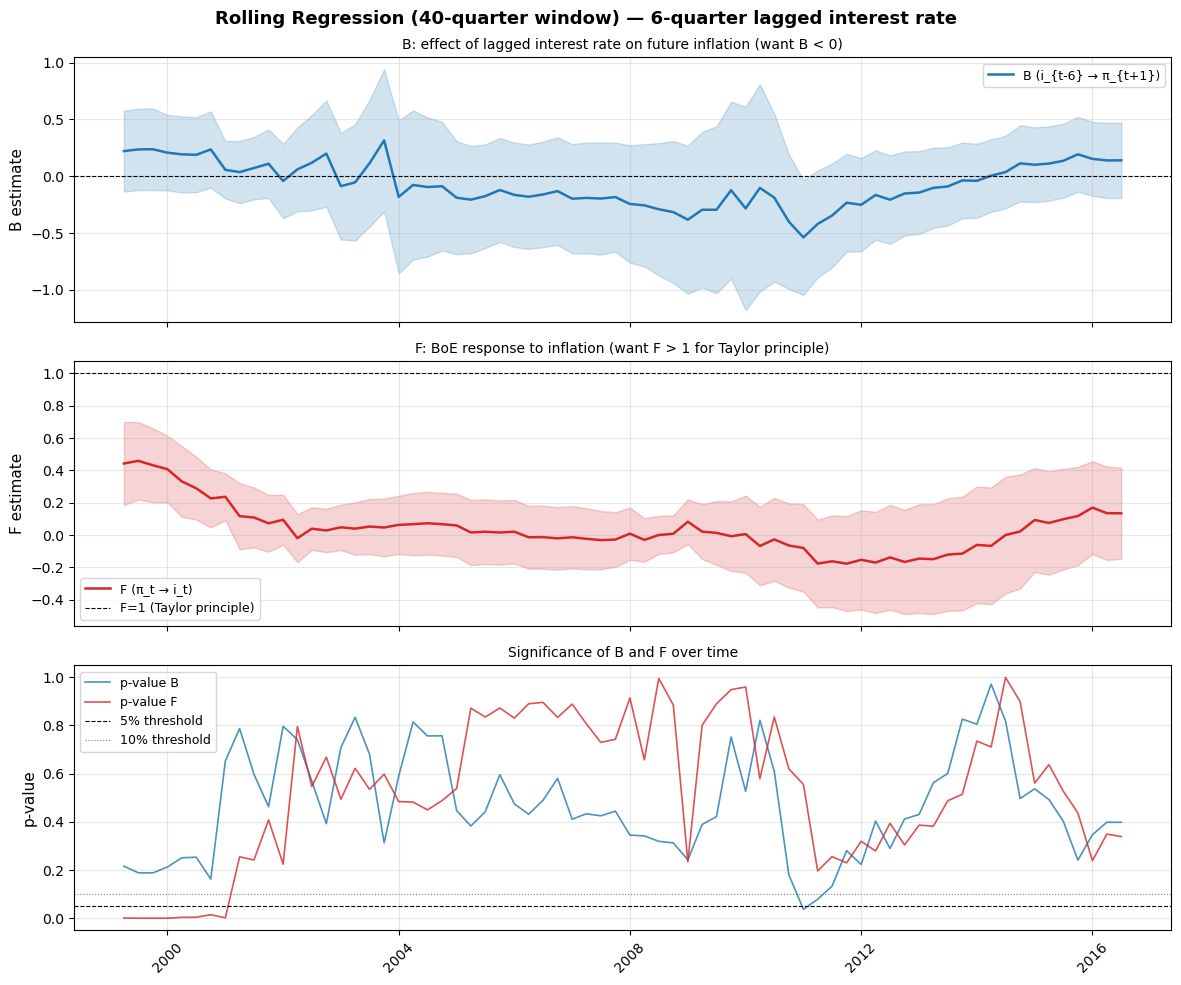


Plot saved as rolling_regression_q31.png


In [162]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

y_t  = final_df["Output_Gap_Annualised"]
pi_t = testing_df_merged["CPI_Log_Inflation_Annualised"]
i_t  = testing_df_merged["PolicyRate"]

instrument_cols = [
    "Unemployment_Rate", "Employment_Growth", "LongRate", "M1_Growth",
    "M3_Growth", "Credit_Growth", "Debt_to_GDP", "GovExp_Growth",
    "GBPUSD_LogDiff", "HPI_Growth", "Equity_Return", "Oil_LogDiff",
    "ConsumerConfidence"
]

# ===========================================================================
# QUESTION 30 — Weak instrument check: R² > 0.1 in both reduced form equations
# ===========================================================================

print("=" * 70)
print("QUESTION 30 — WEAK INSTRUMENT CHECK  (R² > 0.1 in both equations)")
print("=" * 70)
print(f"\n{'Instrument':<22} {'R²(π eq)':>10} {'R²(i eq)':>10} {'Pass π':>8} {'Pass i':>8} {'Both':>8}")
print("-" * 70)

q30_results = []
for z_name in instrument_cols:
    try:
        z_t  = testing_df_merged[z_name].ffill()
        base = pd.concat([pi_t, i_t, y_t, z_t], axis=1).dropna()
        if len(base) < 20:
            continue
        _pi = base["CPI_Log_Inflation_Annualised"]
        _i  = base["PolicyRate"]
        _y  = base["Output_Gap_Annualised"]
        _z  = base[z_name]

        rf_pi = sm.OLS(_pi, sm.add_constant(pd.concat([_y, _z], axis=1))).fit()
        rf_i  = sm.OLS(_i,  sm.add_constant(pd.concat([_y, _z], axis=1))).fit()

        r2_pi   = rf_pi.rsquared
        r2_i    = rf_i.rsquared
        pass_pi = r2_pi > 0.1
        pass_i  = r2_i  > 0.1
        both    = pass_pi and pass_i

        q30_results.append({"Instrument": z_name, "R2_pi": r2_pi, "R2_i": r2_i, "Both": both})
        print(f"{z_name:<22} {r2_pi:>10.4f} {r2_i:>10.4f} "
              f"{'✓' if pass_pi else '✗':>8} {'✓' if pass_i else '✗':>8} "
              f"{'✓ PASS' if both else '✗ FAIL':>8}")
    except Exception as e:
        print(f"{z_name:<22}  Error: {e}")

q30_df   = pd.DataFrame(q30_results)
passlist = q30_df[q30_df["Both"]]["Instrument"].tolist()
print(f"\nInstruments passing both R² > 0.1: {passlist}")


# ===========================================================================
# QUESTION 31 — Rolling regression with 6-quarter lag
#
# Model:
#   Inflation eq:  pi_{t+1} = A*pi_{t-1} + B*i_{t-6} + u_{t+1}
#   Interest eq:   i_t      = F*pi_t     + u_{t+1}
#
# Rolling window = 40 quarters (~10 years)
# ===========================================================================

print("\n\n" + "=" * 70)
print("QUESTION 31 — ROLLING REGRESSION WITH 6-QUARTER LAG")
print("=" * 70)

base_roll = pd.concat([pi_t, i_t], axis=1).dropna().sort_index()
base_roll.columns = ["pi", "i"]

base_roll["pi_lead1"] = base_roll["pi"].shift(-1)
base_roll["pi_lag1"]  = base_roll["pi"].shift(1)
base_roll["i_lag6"]   = base_roll["i"].shift(6)

base_roll = base_roll.dropna()

WINDOW = 40

dates_roll = []
B_roll, A_roll, F_roll = [], [], []
B_ci_lo, B_ci_hi       = [], []
F_ci_lo, F_ci_hi       = [], []
B_pvals, F_pvals       = [], []

for end in range(WINDOW, len(base_roll) + 1):
    window = base_roll.iloc[end - WINDOW : end]

    X_pi = sm.add_constant(window[["pi_lag1", "i_lag6"]])
    m_pi = sm.OLS(window["pi_lead1"], X_pi).fit()

    X_i  = sm.add_constant(window[["pi"]])
    m_i  = sm.OLS(window["i"], X_i).fit()

    dates_roll.append(base_roll.index[end - 1])
    A_roll.append(m_pi.params.get("pi_lag1", np.nan))
    B_roll.append(m_pi.params.get("i_lag6",  np.nan))
    F_roll.append(m_i.params.get("pi",       np.nan))

    B_ci_lo.append(m_pi.conf_int().loc["i_lag6",  0])
    B_ci_hi.append(m_pi.conf_int().loc["i_lag6",  1])
    F_ci_lo.append(m_i.conf_int().loc["pi",       0])
    F_ci_hi.append(m_i.conf_int().loc["pi",       1])
    B_pvals.append(m_pi.pvalues.get("i_lag6", np.nan))
    F_pvals.append(m_i.pvalues.get("pi",      np.nan))

roll_df = pd.DataFrame({
    "date":   dates_roll,
    "A":      A_roll,
    "B":      B_roll,
    "F":      F_roll,
    "B_lo":   B_ci_lo,
    "B_hi":   B_ci_hi,
    "F_lo":   F_ci_lo,
    "F_hi":   F_ci_hi,
    "B_pval": B_pvals,
    "F_pval": F_pvals,
})

if hasattr(roll_df["date"].iloc[0], "to_timestamp"):
    roll_df["date"] = roll_df["date"].apply(lambda x: x.to_timestamp())

print(f"\nRolling window: {WINDOW} quarters")
print(f"Total windows:  {len(roll_df)}")
print(f"\nProportion of windows where B < 0 (correct sign): "
      f"{(roll_df['B'] < 0).mean():.1%}")
print(f"Proportion of windows where F > 0 (Taylor principle): "
      f"{(roll_df['F'] > 0).mean():.1%}")
print(f"Proportion of windows where B significant (p<0.1):  "
      f"{(roll_df['B_pval'] < 0.1).mean():.1%}")
print(f"Proportion of windows where F significant (p<0.1):  "
      f"{(roll_df['F_pval'] < 0.1).mean():.1%}")

print(f"\nFull-sample OLS (not rolling) for reference:")
X_pi_full = sm.add_constant(base_roll[["pi_lag1", "i_lag6"]])
m_pi_full = sm.OLS(base_roll["pi_lead1"], X_pi_full).fit()
X_i_full  = sm.add_constant(base_roll[["pi"]])
m_i_full  = sm.OLS(base_roll["i"], X_i_full).fit()
print(f"  A = {m_pi_full.params['pi_lag1']:.4f}  "
      f"B = {m_pi_full.params['i_lag6']:.4f} (p={m_pi_full.pvalues['i_lag6']:.4f})  "
      f"F = {m_i_full.params['pi']:.4f} (p={m_i_full.pvalues['pi']:.4f})")
print(f"  Inflation eq R² = {m_pi_full.rsquared:.4f}   "
      f"Interest rate eq R² = {m_i_full.rsquared:.4f}")
print(m_pi_full.summary())
print(m_i_full.summary())


fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle("Rolling Regression (40-quarter window) — 6-quarter lagged interest rate",
             fontsize=13, fontweight="bold", y=0.98)

ax1, ax2, ax3 = axes

ax1.plot(roll_df["date"], roll_df["B"], color="#1f77b4", linewidth=1.8, label="B (i_{t-6} → π_{t+1})")
ax1.fill_between(roll_df["date"], roll_df["B_lo"], roll_df["B_hi"], alpha=0.2, color="#1f77b4")
ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.set_ylabel("B estimate", fontsize=11)
ax1.set_title("B: effect of lagged interest rate on future inflation (want B < 0)", fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.plot(roll_df["date"], roll_df["F"], color="#d62728", linewidth=1.8, label="F (π_t → i_t)")
ax2.fill_between(roll_df["date"], roll_df["F_lo"], roll_df["F_hi"], alpha=0.2, color="#d62728")
ax2.axhline(1, color="black", linewidth=0.8, linestyle="--", label="F=1 (Taylor principle)")
ax2.set_ylabel("F estimate", fontsize=11)
ax2.set_title("F: BoE response to inflation (want F > 1 for Taylor principle)", fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

ax3.plot(roll_df["date"], roll_df["B_pval"], color="#1f77b4", linewidth=1.2,
         label="p-value B", alpha=0.8)
ax3.plot(roll_df["date"], roll_df["F_pval"], color="#d62728", linewidth=1.2,
         label="p-value F", alpha=0.8)
ax3.axhline(0.05, color="black", linewidth=0.8, linestyle="--", label="5% threshold")
ax3.axhline(0.10, color="gray",  linewidth=0.8, linestyle=":",  label="10% threshold")
ax3.set_ylabel("p-value", fontsize=11)
ax3.set_title("Significance of B and F over time", fontsize=10)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax3.xaxis.set_major_locator(mdates.YearLocator(4))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("rolling_regression_q31.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved as rolling_regression_q31.png")